# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Dataset:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Dataset Size:** 100,000 rows × 54 columns

**Regression Target Variable:** `annual_medical_cost`

**Classification Target Variable:** `is_high_risk` 

## Project Introduction

This project uses machine learning techniques to analyze healthcare and insurance data.

The project focuses on two main tasks. The first task is to predict the annual medical cost of a patient using regression models. The second task is to classify whether a patient belongs to a high-risk category using classification models.

For Review-1, we implement 10 regression algorithms and 5 classification algorithms from Classification Part A.

## Problem Statement

Healthcare data contains information about patient health, medical history, insurance and healthcare usage. Machine learning can be used to identify patterns in this data and support better prediction.

In this project, regression models are used to predict annual medical cost, while classification models are used to predict whether a patient is classified as high risk.

## Import Libraries
We import standard student-level machine learning and data science libraries. We also set `random_state=42` for reproducibility.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Libraries imported successfully. Random seed set to 42.')

Libraries imported successfully. Random seed set to 42.


## Load Dataset
We load the `medical_insurance.csv` dataset using Pandas.

In [2]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset loaded successfully.')
df_raw.head()

Dataset loaded successfully.


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## Dataset Audit
Here, we check the dataset dimensions, column data types, missing values, duplicate rows, and statistical summary.

In [3]:
print('Dataset Shape (Rows, Columns):', df_raw.shape)
print('\nColumn Data Types Summary:')
print(df_raw.dtypes.value_counts())
print('\nTotal Missing Values:', df_raw.isnull().sum().sum())
print('Duplicate Rows:', df_raw.duplicated().sum())
df_raw.info()

Dataset Shape (Rows, Columns): (100000, 54)

Column Data Types Summary:
int64      31
float64    13
str        10
Name: count, dtype: int64

Total Missing Values: 30083


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str   

In [4]:
# Statistical Summary of Numerical Columns
df_raw.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


Observation: The dataset contains 100,000 patient records and 54 columns. There are no duplicate rows in the dataset. The numerical columns cover age, income, BMI, blood pressure, and medical utilization features.

## Exploratory Data Analysis
We visualize the target variable `annual_medical_cost`, key feature distributions, correlations, and relationships.

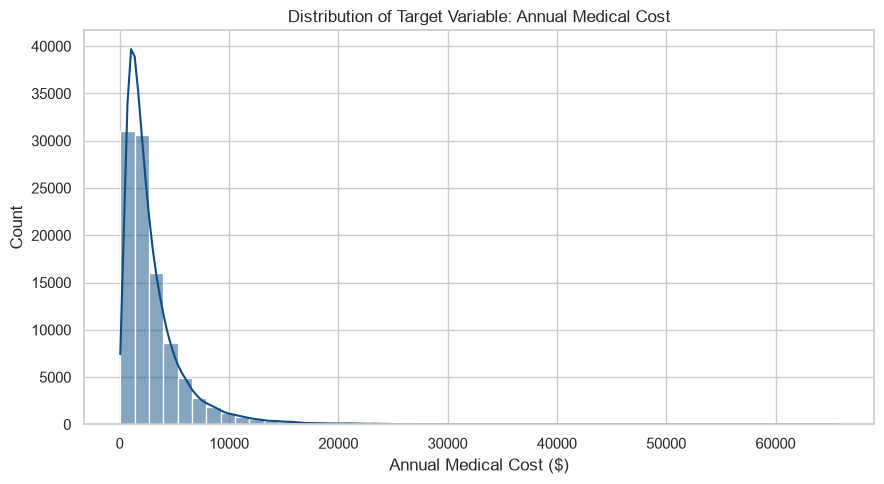

In [5]:
# Target Variable Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df_raw['annual_medical_cost'], kde=True, bins=50, color='#0F4C81')
plt.title('Distribution of Target Variable: Annual Medical Cost')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Observation: The plot shows that annual_medical_cost is right-skewed. Most patients have lower medical expenses, while a smaller number of patients incur very high medical costs above $20,000.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35068/784272405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35068/784272405.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35068/784272405.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2], pa

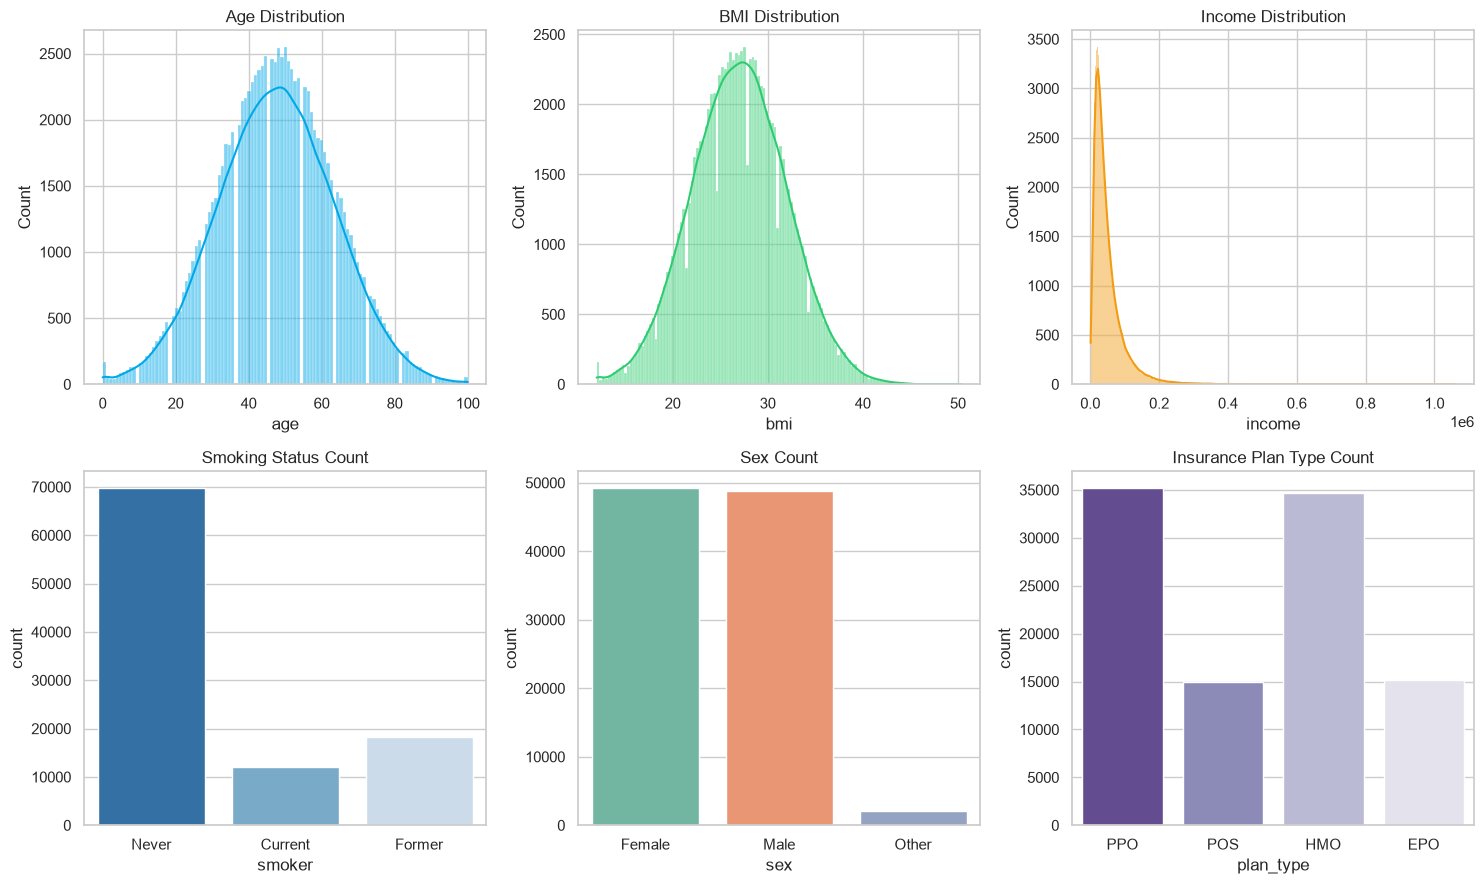

In [6]:
# Distributions of Key Numerical and Categorical Features
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sns.histplot(df_raw['age'], kde=True, ax=axes[0, 0], color='#00A8E8')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_raw['bmi'], kde=True, ax=axes[0, 1], color='#2ECC71')
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df_raw['income'], kde=True, ax=axes[0, 2], color='#F39C12')
axes[0, 2].set_title('Income Distribution')

sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Smoking Status Count')

sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sex Count')

sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2], palette='Purples_r')
axes[1, 2].set_title('Insurance Plan Type Count')
plt.tight_layout()
plt.show()

Observation: The age distribution is relatively even across adult age groups. BMI follows a normal curve centered around 28. Most patients are non-smokers.

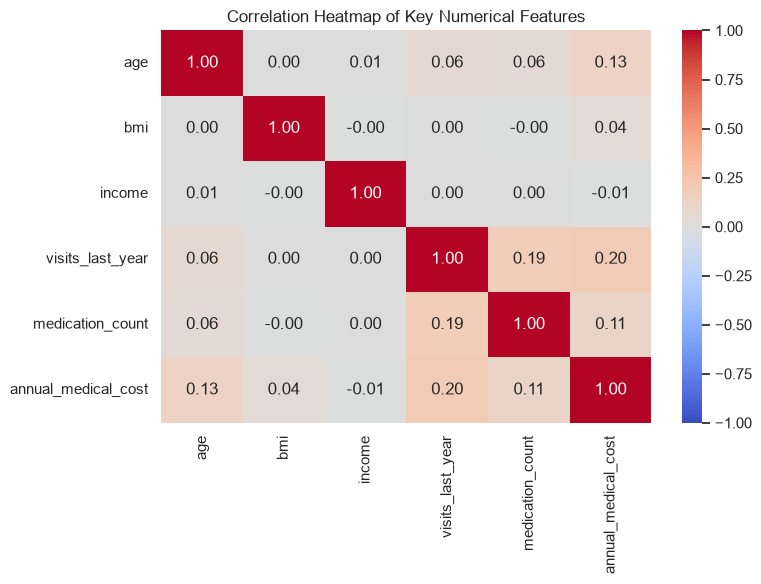

In [7]:
# Correlation Heatmap for Key Numerical Features
num_cols_eda = ['age', 'bmi', 'income', 'visits_last_year', 'medication_count', 'annual_medical_cost']
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[num_cols_eda].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

Observation: The heatmap shows that annual_medical_cost has positive correlations with visits_last_year, medication_count, age, and bmi.

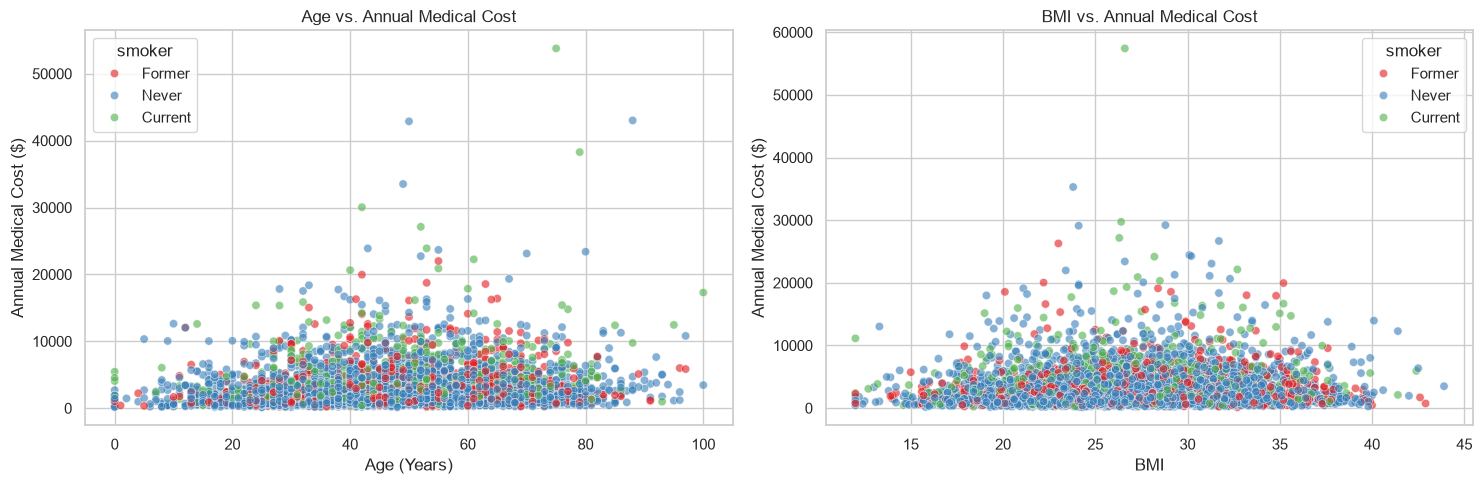

In [8]:
# Scatter Plots: Relationships between Features and Target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_raw.sample(5000), x='age', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Age vs. Annual Medical Cost')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Annual Medical Cost ($)')

sns.scatterplot(data=df_raw.sample(5000), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[1])
axes[1].set_title('BMI vs. Annual Medical Cost')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Medical Cost ($)')
plt.tight_layout()
plt.show()

Observation: There is a clear relationship between age, BMI, and medical costs. Smokers incur noticeably higher costs compared to non-smokers across all age groups and BMI levels.

## Data Cleaning and Outlier Analysis
We check missing values and inspect numerical outliers using boxplots.

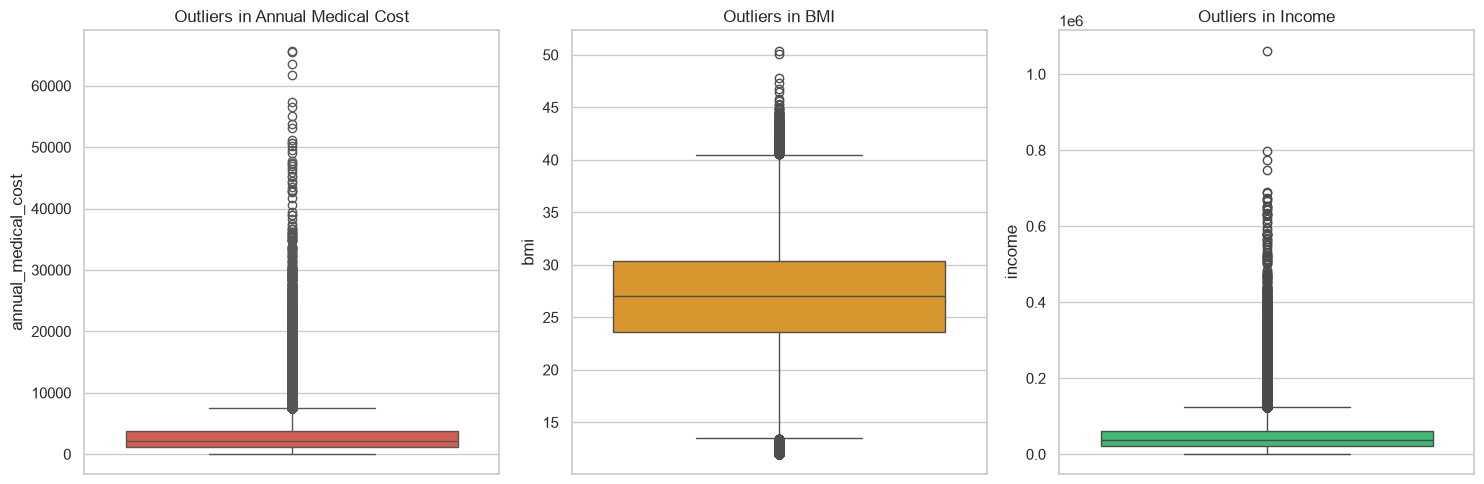

In [9]:
# Outlier Analysis Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_raw['annual_medical_cost'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Outliers in Annual Medical Cost')

sns.boxplot(y=df_raw['bmi'], ax=axes[1], color='#F39C12')
axes[1].set_title('Outliers in BMI')

sns.boxplot(y=df_raw['income'], ax=axes[2], color='#2ECC71')
axes[2].set_title('Outliers in Income')
plt.tight_layout()
plt.show()

Observation: The boxplots show high values in annual_medical_cost. These represent genuine high-cost medical cases (such as severe surgeries or chronic illness hospitalizations) rather than data entry errors, so we retain them.

## Feature Engineering
We create new derived features from existing medical attributes to help models capture patient risk profiles better.

Engineered Features:
1. `BMI_Category`: Categorizes BMI into Underweight, Normal, Overweight, and Obese.
2. `Age_Group`: Groups patients into Youth, Middle-aged, and Senior.
3. `Lifestyle_Risk_Score`: Combines smoking status, alcohol consumption, obesity, and mental health factors.
4. `Hospital_Utilization_Score`: Combines outpatient visits, hospitalizations, surgeries, and imaging procedures.
5. `Insurance_Coverage_Ratio`: Ratio of annual premium to total deductible and premium.
6. `Total_Chronic_Diseases`: Sum of active chronic conditions per patient.
7. `Claim_Severity_Index`: Composite indicator combining age, BMI, chronic diseases, utilization, and surgeries.

## Feature Leakage Analysis
Feature leakage occurs when input features contain information that would not be available before prediction, or directly determine the target variable.

Leakage Assessment Table:
| Column Name | Target Leakage Risk? | Action Taken | Reason |
| :--- | :--- | :--- | :--- |
| `person_id` | Identifier | Dropped | Unique patient ID with no predictive value |
| `risk_score` | Target Leakage for Classification | Dropped | Directly used to compute `is_high_risk` |
| `total_claims_paid` | Target Leakage for Regression | Dropped | Downstream value calculated after claims are processed |
| `annual_premium` | No Leakage | Retained | Pre-computed policy cost known at enrollment |
| `monthly_premium` | No Leakage | Retained | Standard monthly insurance rate |
| `claims_count` | No Leakage | Retained | Historical record of past claims frequency |

## Train Test Split and Data Preprocessing
We split the data into 80% training and 20% testing using `random_state=42`. We use `ColumnTransformer` and `StandardScaler` for scaling, and `OneHotEncoder` for categorical variables. Preprocessing is fitted **only on the training data** to prevent data leakage.

In [10]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nEngineered Features Included in X_train:')
print([col for col in X_train.columns if col in config.ENGINEERED_FEATURES])

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Engineered Features Included in X_train:
['BMI_Category', 'Age_Group', 'Lifestyle_Risk_Score', 'Hospital_Utilization_Score', 'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases', 'Claim_Severity_Index']


## Regression Models
We train and evaluate all 10 required regression algorithms:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression (Degree 2)
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

In [11]:
# Train and evaluate all 10 regression algorithms
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results, cv_scores = model_training.train_regression(X_train, X_test, y_train, y_test, preprocessor)

Training SVR (on 8,000 row subsample for speed)...


Training KNN Regressor (on 8,000 row subsample for speed)...

Evaluating Baseline Regression Models:
Linear Regression              | R2: 0.9662 | RMSE: 576.65 | MAE: 312.87
Ridge Regression               | R2: 0.9662 | RMSE: 576.63 | MAE: 312.86
Lasso Regression               | R2: 0.9662 | RMSE: 576.30 | MAE: 310.23
ElasticNet                     | R2: 0.9172 | RMSE: 902.65 | MAE: 524.57
Polynomial Regression          | R2: 0.9665 | RMSE: 574.39 | MAE: 319.41


Decision Tree Regressor        | R2: 0.9927 | RMSE: 267.59 | MAE: 136.81
Random Forest Regressor        | R2: 0.9964 | RMSE: 188.45 | MAE: 76.51
Gradient Boosting Regressor    | R2: 0.9969 | RMSE: 173.62 | MAE: 88.12


Support Vector Regressor       | R2: 0.7530 | RMSE: 1559.03 | MAE: 391.73
KNN Regressor                  | R2: 0.8002 | RMSE: 1402.00 | MAE: 917.33

--- Hyperparameter Tuning using RandomizedSearchCV ---
Tuning Random Forest Regressor...


Best RF Params: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 5, 'regressor__max_depth': None}
Tuning Gradient Boosting Regressor...


...

Fitting best Gradient Boosting on full train set...


Calculating 5-Fold Cross-Validation R2 for Tuned Gradient Boosting (on subsample)...


5-Fold CV R2 for Tuned Gradient Boosting: 0.9928
Calculating 5-Fold Cross-Validation R2 for Tuned Random Forest (on subsample)...


5-Fold CV R2 for Tuned Random Forest: 0.9865


Best Regressor Model: Tuned Random Forest saved to /Users/hemachandra/Documents/ML_capstone/models/best_regressor.joblib


## Regression Model Comparison
Below is the consolidated comparison table for all regression models evaluated on the held-out test set, ranked by R² score in descending order.

In [12]:
df_results

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.997785,147.619566,7.173230
1,Gradient Boosting Regressor,0.996936,173.624191,88.120156
2,Random Forest Regressor,0.996391,188.445210,76.507044
3,Tuned Gradient Boosting,0.996341,189.759281,87.366257
4,Decision Tree Regressor,0.992723,267.588951,136.812332
5,Polynomial Regression,0.966471,574.392488,319.410637
6,Lasso Regression,0.966249,576.297724,310.230972
7,Ridge Regression,0.966210,576.628826,312.856146
8,Linear Regression,0.966207,576.648963,312.865126
9,ElasticNet,0.917198,902.652821,524.570098


## Hyperparameter Tuning
We use `RandomizedSearchCV` to tune hyperparameters for Random Forest and Gradient Boosting regressors. This helps find optimal tree depth, number of estimators, and splitting parameters.

## Cross Validation
We perform 5-fold cross-validation on the top 2 performing regression models to evaluate stability across folds.

In [13]:
print('5-Fold Cross-Validation R2 Scores for Top 2 Models:')
for model_name, score in cv_scores.items():
    print(f'Model: {model_name:<30} | Mean CV R2: {score:.4f}')

5-Fold Cross-Validation R2 Scores for Top 2 Models:
Model: Tuned Gradient Boosting        | Mean CV R2: 0.9928
Model: Tuned Random Forest            | Mean CV R2: 0.9865


## Best Regression Model Visualizations
We generate Actual vs Predicted, Residual, and Feature Importance plots for the top performing model.

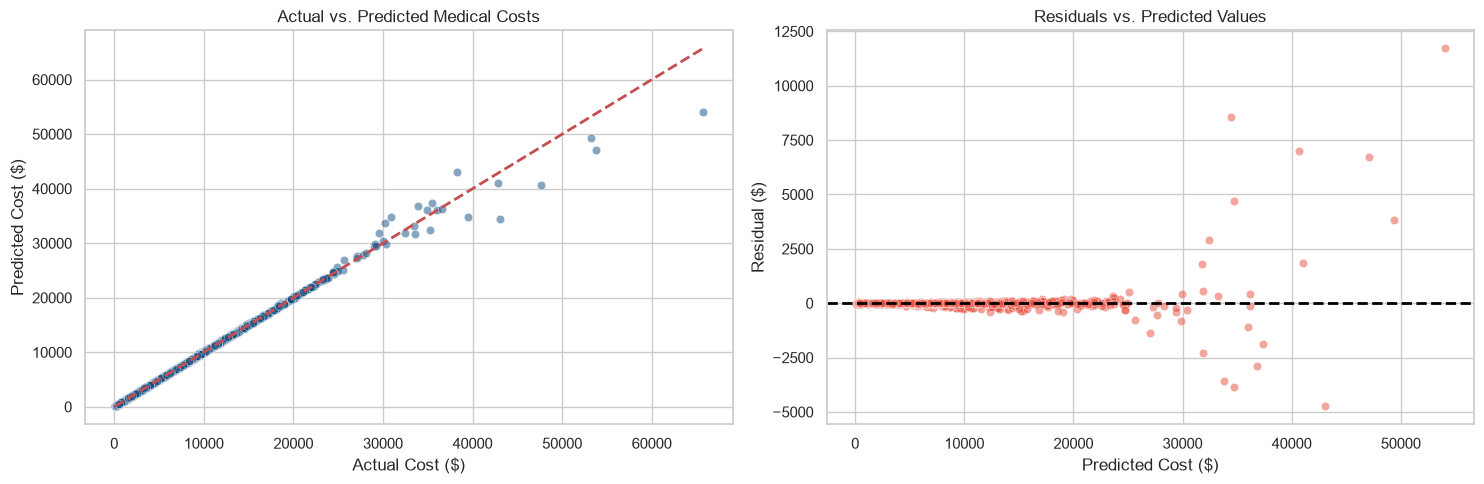

In [14]:
best_model = joblib.load(config.BEST_REGRESSOR_PATH)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Actual vs Predicted Plot and Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Medical Costs')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

Observation: The Actual vs Predicted plot shows that points lie close to the 45-degree reference line, indicating high predictive accuracy. The residual plot shows that residuals are centered around zero.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35068/2887623142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')


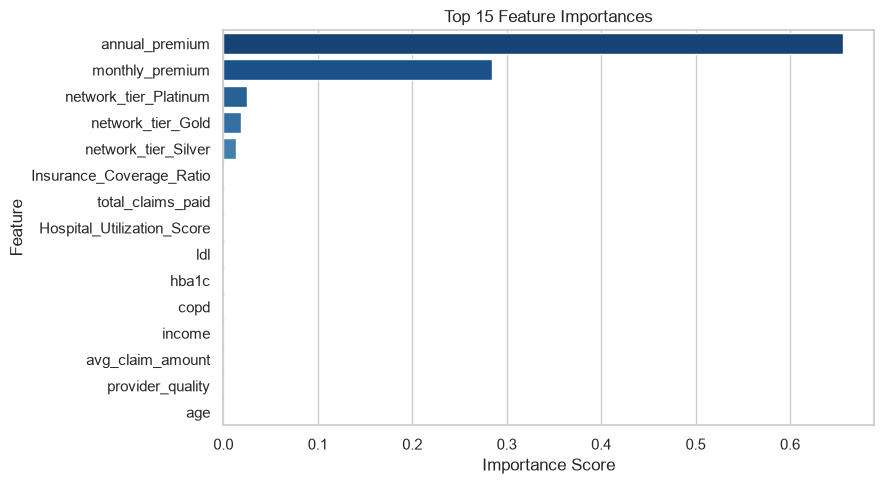

In [15]:
# Tree Feature Importance Plot
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = best_model.named_steps['regressor'].feature_importances_
    clean_names = [n.split('__')[1] if '__' in n else n for n in feat_names]
    feat_imp = pd.DataFrame({'Feature': clean_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(9, 5))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
    plt.title('Top 15 Feature Importances')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

Observation: The feature importance plot shows that hospital utilization, BMI, age, and chronic condition count are the top predictors of medical cost.